# Template notebook

It's good to start with an introduction, to set the scene and introduce your audience to the data, and the problem you're solving as a team.

<br>

## Libraries
As always, we'll start by importing the necessary libraries.

In [3]:
# It's good practice to add comments to explain your code 
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from itertools import combinations

In [26]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.model_selection import train_test_split

In [5]:
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix,
    classification_report, average_precision_score,
    f1_score, precision_score, recall_score
)

In [6]:
pd.set_option('future.no_silent_downcasting', True)

In [7]:
def kde_plot(xv: np.array, yv: np.array, y_limit=None, x_limit=None):
    p = ['#888888', '#f6b48f', '#f37651', '#e13342', '#ad1759', '#701f57', '#35193e']
    if xv.ndim == 1:
        fig, ax = plt.subplots(1, figsize=(7, 7))
        sns.kdeplot(data=pd.DataFrame(np.vstack([xv, yv])).T,
                x=0,
                hue=1,
                palette=dict(zip(sorted(set(yv)), p)),
                ax=ax
               )
        if y_limit:
            ax.set_ylim(y_limit)
        if x_limit:
            ax.set_xlim(x_limit)
    else:
        rows = int(np.ceil(xv.shape[1]/2))
        fig, ax = plt.subplots(nrows=rows, ncols=2, figsize=(12, 13))
        for i in range(xv.shape[1]):
            r = i // 2
            c = i % 2
            try: 
                curr_axis = ax[r][c]
            except:
                curr_axis = ax[c]
            leg_setting = True if all([r==0, c==0]) else False
            sns.kdeplot(data=pd.DataFrame(np.vstack([xv[:,i], yv])).T,
                        x=0,
                        hue=1,
                        palette=dict(zip(sorted(set(yv)), p)),
                        legend=leg_setting,
                        ax = curr_axis,
                    )
            if leg_setting: 
                sns.move_legend(curr_axis, "center", bbox_to_anchor=(1, 1.2), ncol=len(set(yv)), markerscale=15, title=None)
            if y_limit:
                curr_axis.set_ylim(y_limit)
            if x_limit:
                curr_axis.set_xlim(x_limit)
    plt.show()
    return

In [8]:
def violin_plot(xv: np.array, yv: np.array):
    p = ['#888888', '#f6b48f', '#f37651', '#e13342', '#ad1759', '#701f57', '#35193e']
    fig, ax = plt.subplots(1, figsize=(7, 7))
    sns.violinplot(data=pd.DataFrame(np.vstack([xv, yv])).T,
            x=1,
            y=0,
            hue=1,
            palette=dict(zip(sorted(set(yv)), p)),
            ax=ax
            )
    plt.show()
    return

In [9]:
def evaluate_model(y_true, y_prob, y_pred=None, threshold=0.5, model_name="Model"):

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    if y_pred is None:
        y_pred = (y_prob >= threshold).astype(int)
    else:
        y_pred = np.asarray(y_pred)

    # Metrics
    auc  = roc_auc_score(y_true, y_prob)
    ap   = average_precision_score(y_true, y_prob)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    npv         = tn / (tn + fn) if (tn + fn) > 0 else 0.0

    # Console output
    width = 42
    print("=" * width)
    print(f"  {model_name}  |  threshold = {threshold:.2f}")
    print("=" * width)
    print(f"  {'ROC-AUC':<22} {auc:.4f}")
    print(f"  {'Avg Precision (PR-AUC)':<22} {ap:.4f}")
    print(f"  {'F1 Score':<22} {f1:.4f}")
    print("-" * width)
    print(f"  {'Precision (PPV)':<22} {prec:.4f}")
    print(f"  {'Recall (Sensitivity)':<22} {rec:.4f}")
    print(f"  {'Specificity':<22} {specificity:.4f}")
    print(f"  {'NPV':<22} {npv:.4f}")
    print("-" * width)
    print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
    print("=" * width)
    print()
    print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

    # Plots
    DARK   = "#0f1117"
    MID    = "#1c1f2b"
    ACCENT = "#4f8ef7"
    GREEN  = "#3ecf8e"
    RED    = "#f76b6b"
    GREY   = "#8892a4"
    WHITE  = "#e8ecf4"

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)

    fig = plt.figure(figsize=(10, 4.2), facecolor=DARK)
    gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.38)

    # — ROC curve —
    ax1 = fig.add_subplot(gs[0])
    ax1.set_facecolor(MID)

    ax1.fill_between(fpr, tpr, alpha=0.12, color=ACCENT)
    ax1.plot(fpr, tpr, color=ACCENT, lw=2, label=f"AUC = {auc:.3f}")
    ax1.plot([0, 1], [0, 1], "--", color=GREY, lw=1, label="Random")

    # Mark the chosen threshold operating point
    op_idx = np.argmin(np.abs(thresholds - threshold))
    ax1.scatter(fpr[op_idx], tpr[op_idx], s=70, color=GREEN,
                zorder=5, label=f"Threshold {threshold:.2f}")

    ax1.set_xlim(-0.02, 1.02)
    ax1.set_ylim(-0.02, 1.05)
    ax1.set_xlabel("False Positive Rate", color=GREY, fontsize=9)
    ax1.set_ylabel("True Positive Rate", color=GREY, fontsize=9)
    ax1.set_title("ROC Curve", color=WHITE, fontsize=10, fontweight="bold", pad=8)
    ax1.tick_params(colors=GREY, labelsize=8)
    for spine in ax1.spines.values():
        spine.set_edgecolor("#2e3347")
    ax1.legend(fontsize=8, framealpha=0.25, labelcolor=WHITE,
               facecolor=MID, edgecolor="#2e3347")

    # — Confusion matrix —
    ax2 = fig.add_subplot(gs[1])
    ax2.set_facecolor(MID)

    cm = np.array([[tn, fp], [fn, tp]])
    labels = np.array([
        [f"TN\n{tn}", f"FP\n{fp}"],
        [f"FN\n{fn}", f"TP\n{tp}"]
    ])
    cell_colors = np.array([[GREEN, RED], [RED, GREEN]])
    alphas = cm / cm.max()

    for i in range(2):
        for j in range(2):
            alpha = 0.15 + 0.55 * alphas[i, j]
            ax2.add_patch(plt.Rectangle(
                (j - 0.5, i - 0.5), 1, 1,
                color=cell_colors[i, j], alpha=alpha
            ))
            ax2.text(j, i, labels[i, j], ha="center", va="center",
                     fontsize=11, fontweight="bold", color=WHITE)

    ax2.set_xlim(-0.5, 1.5)
    ax2.set_ylim(-0.5, 1.5)
    ax2.set_xticks([0, 1])
    ax2.set_yticks([0, 1])
    ax2.set_xticklabels(["Pred Neg", "Pred Pos"], color=GREY, fontsize=8)
    ax2.set_yticklabels(["Actual Neg", "Actual Pos"], color=GREY, fontsize=8)
    ax2.set_title("Confusion Matrix", color=WHITE, fontsize=10,
                  fontweight="bold", pad=8)
    ax2.invert_yaxis()
    for spine in ax2.spines.values():
        spine.set_edgecolor("#2e3347")

    fig.suptitle(model_name, color=WHITE, fontsize=12, fontweight="bold", y=1.02)
#     plt.tight_layout()
    plt.show()

    return {
        "auc": auc, "avg_precision": ap, "f1": f1,
        "precision": prec, "recall": rec,
        "specificity": specificity, "npv": npv,
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn)
    }

## Read Data

In [10]:
data = pd.read_csv('data/corona_tested_individuals_ver_006.english.csv')
data.shape

/tmp/ipykernel_30/2267328107.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/corona_tested_individuals_ver_006.english.csv')


(278848, 10)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278848 entries, 0 to 278847
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   test_date            278848 non-null  object 
 1   cough                278596 non-null  float64
 2   fever                278596 non-null  float64
 3   sore_throat          278847 non-null  float64
 4   shortness_of_breath  278847 non-null  float64
 5   head_ache            278847 non-null  float64
 6   corona_result        278848 non-null  object 
 7   age_60_and_above     151528 non-null  object 
 8   gender               259285 non-null  object 
 9   test_indication      278848 non-null  object 
dtypes: float64(5), object(5)
memory usage: 21.3+ MB


# Prep

In [13]:
valid_data = data[data['corona_result'].isin(['positive', 'negative'])].copy()

In [14]:
# TEST_DATE
# extract year and month from date
valid_data['test_date'] = pd.to_datetime(valid_data['test_date'])
valid_data['date_ord'] = valid_data['test_date'].rank(method='dense')
print('Date range: ', valid_data['date_ord'].max(), 'days')

Date range:  51.0 days


In [15]:
# AGE
valid_data['age_60_and_above'] = valid_data['age_60_and_above'].fillna('No')
valid_data['age_60_and_above'] = valid_data['age_60_and_above'].replace('Yes', 1).replace('No', 0)
print('Age:', valid_data['age_60_and_above'].value_counts(dropna=False))

Age: age_60_and_above
0    249531
1     25425
Name: count, dtype: int64


In [16]:
# GENDER
valid_data['male'] = valid_data['gender'] == 'male'
print('Gender:', valid_data['gender'].value_counts(dropna=False))
print('\nMale:', valid_data['male'].value_counts(dropna=False))

Gender: gender
female    128541
male      127370
NaN        19045
Name: count, dtype: int64

Male: male
False    147586
True     127370
Name: count, dtype: int64


In [17]:
# TEST_INDICATION
valid_data['abroad'] = valid_data['test_indication'] == 'Abroad'
valid_data['contact_confirmed'] = valid_data['test_indication'] == 'Contact with confirmed'

print('Abroad:', valid_data['abroad'].value_counts(dropna=False))
print('\nConfirmed Contact:', valid_data['contact_confirmed'].value_counts(dropna=False))

Abroad: abroad
False    249882
True      25074
Name: count, dtype: int64

Confirmed Contact: contact_confirmed
False    264478
True      10478
Name: count, dtype: int64


In [18]:
# # PREV DAY SAMPLES
# prev_samples_dict = valid_data.groupby('test_date').size().shift(1).to_dict()
# valid_data['prev_samples'] = valid_data['test_date'].map(prev_samples_dict)

# fig = plt.figure(figsize=(10, 2))
# plt.title('Previous Day # Samples')
# sns.histplot(valid_data['prev_samples'])

In [19]:
symptoms = ['cough', 'fever', 'sore_throat', 'shortness_of_breath', 'head_ache']
symptoms_comb = list(combinations(symptoms, 2))
print('Number of symptom combinations', len(symptoms_comb))

results_percent_all = valid_data['corona_result'].value_counts(dropna=False, normalize=True)
pos_result_norm = results_percent_all['positive']
neg_result_norm = results_percent_all['negative']

# rank symptom combinations
combination_data = {}
combination_stats = {}
for c1, c2 in symptoms_comb:
    c1_true = valid_data[c1] == 1
    c2_true = valid_data[c2] == 1
    comb_data = valid_data[c1_true & c2_true].copy()
    results_percent = comb_data['corona_result'].value_counts(dropna=False, normalize=True)
#     print('Combination: ', c1, c2)
#     print('Number of samples: ', len(comb_data))
#     print('Results: ', comb_data['corona_result'].value_counts(dropna=False, normalize=True))
#     print('\n')
    combination_data[(c1, c2)] = comb_data
    
    combination_stats[(c1, c2)] = {
        'samples':len(comb_data),
        'pos_result_percent':results_percent['positive'],
        'neg_result_percent':results_percent['negative'],
        'pos_result_diff':results_percent['positive'] - pos_result_norm,
        'neg_result_diff':results_percent['negative'] - neg_result_norm
    }

Number of symptom combinations 10


In [87]:
sorted_keys = sorted(combination_stats, key=lambda k: combination_stats[k]['pos_result_diff'], reverse=True)
sorted_combination_stats = {x:combination_stats.get(x)['pos_result_diff'] for x in sorted_keys}
sorted_combination_stats

{('fever', 'head_ache'): 0.8935253187454851,
 ('cough', 'head_ache'): 0.8840190868126558,
 ('shortness_of_breath', 'head_ache'): 0.8639314290286446,
 ('sore_throat', 'head_ache'): 0.8632176557144409,
 ('fever', 'sore_throat'): 0.8104763728488693,
 ('fever', 'shortness_of_breath'): 0.7939099038133924,
 ('sore_throat', 'shortness_of_breath'): 0.7661988708891098,
 ('cough', 'sore_throat'): 0.7482258825359855,
 ('cough', 'shortness_of_breath'): 0.735025332666796,
 ('cough', 'fever'): 0.1801002666051198}

In [21]:
# SYMPTOM COMBINATIONS
# all combinations are significantly more positive other than cough and fever,
# so hoping that just summing number of symptoms and flagging cough and fever is enough

valid_data['num_symptoms'] = valid_data[symptoms].sum(axis=1)
# valid_data['cough_and_fever'] = valid_data['cough'].astype(bool) & valid_data['fever'].astype(bool)

In [23]:
# SYMPTOM COMBINATIONS
# all combinations are flagged

combi_values = []
for c1, c2 in symptoms_comb:
    c1_true = valid_data[c1] == 1
    c2_true = valid_data[c2] == 1
    combi_series = (c1_true & c2_true).values
    combi_values.append(combi_series.reshape(-1, 1))
all_combination_features = pd.DataFrame(np.hstack(combi_values), columns=['+'.join(x) for x in symptoms_comb])
valid_data[all_combination_features.columns] = all_combination_features

In [51]:
random_state = 100

# drop columns
drop = [
    'test_date',
    'gender',
    'test_indication'
]
tt_data = valid_data.drop(columns=drop)

# train test split
X = tt_data.drop(columns=['corona_result'])
y = tt_data['corona_result'].astype(object).replace('positive', 1).replace('negative', 0).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)

print('Features: ')
[print(' | '.join(X_train.columns[i:i+4])) for i in range(0, len(X_train.columns), 4)];

Features: 
cough | fever | sore_throat | shortness_of_breath
head_ache | age_60_and_above | date_ord | male
abroad | contact_confirmed | num_symptoms | cough+fever
cough+sore_throat | cough+shortness_of_breath | cough+head_ache | fever+sore_throat
fever+shortness_of_breath | fever+head_ache | sore_throat+shortness_of_breath | sore_throat+head_ache
shortness_of_breath+head_ache


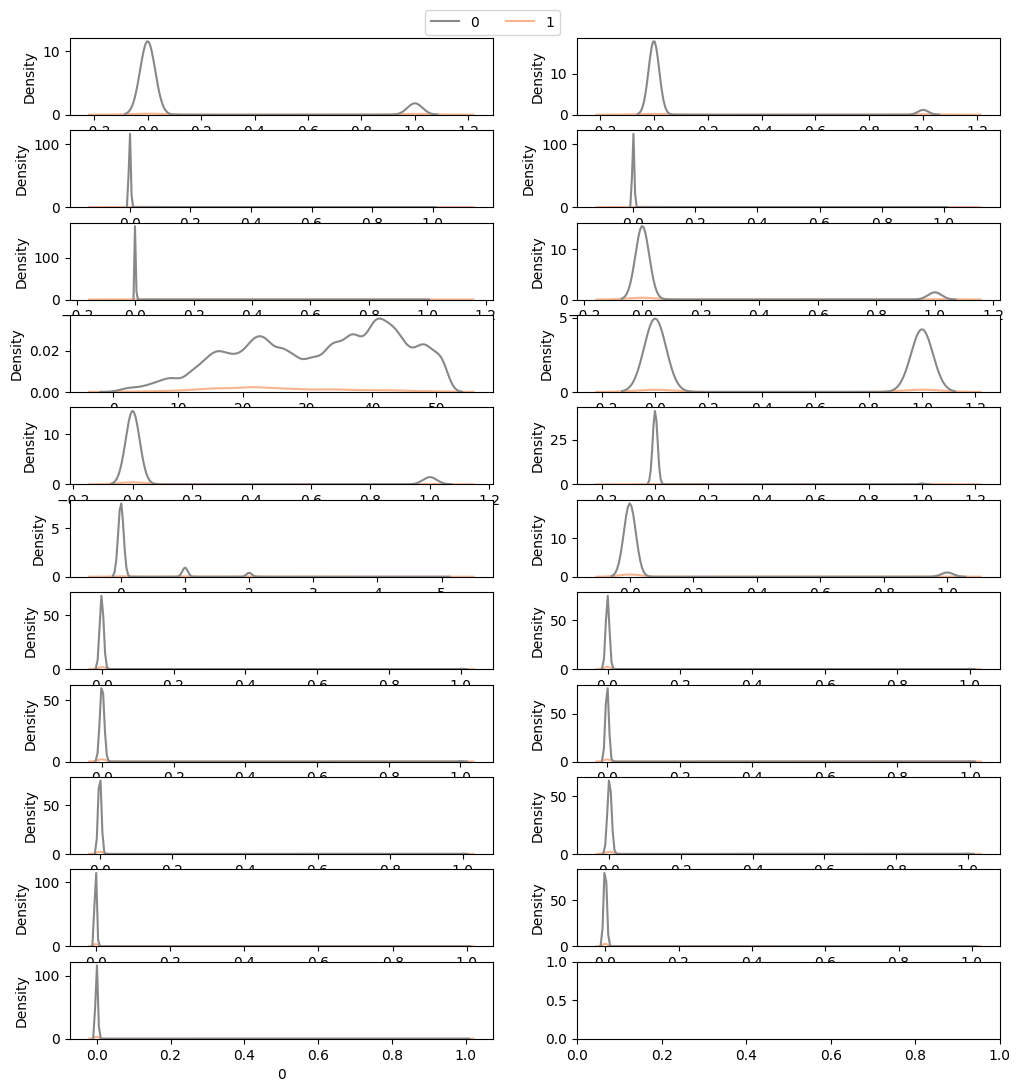

In [84]:
kde_plot(X.values, y)

# Random Forrest

In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
rf = RandomForestClassifier()

In [151]:
rf.get_params()

### Random Search

In [30]:
from scipy.stats import randint
from scipy.stats import uniform, loguniform

In [33]:
rs_params = {
    'min_samples_split':randint(3, 12),
    'min_samples_leaf':randint(3, 12),
    'max_depth':randint(2, 50),
    'max_features':randint(2, len(X_train.columns)),
    'min_impurity_decrease':loguniform(0.0001, 0.15),
    'n_estimators':randint(20, 50),
    'criterion':['gini', 'entropy', 'log_loss'],
#     'class_weight':["balanced"]
}

In [34]:
skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=random_state
)
print('Number of splits in SKFold: ', skf.get_n_splits())

rscv = RandomizedSearchCV(
    estimator=rf,
    cv=skf,
    param_distributions=rs_params,
    n_iter=35,
    random_state=random_state,
    verbose=2
)

rscv.fit(X_train, y_train)

Number of splits in SKFold:  3
Fitting 3 folds for each of 35 candidates, totalling 105 fits
[CV] END criterion=gini, max_depth=26, max_features=5, min_impurity_decrease=0.0020356211958296438, min_samples_leaf=3, min_samples_split=7, n_estimators=22; total time=   0.9s
[CV] END criterion=gini, max_depth=26, max_features=5, min_impurity_decrease=0.0020356211958296438, min_samples_leaf=3, min_samples_split=7, n_estimators=22; total time=   0.8s
[CV] END criterion=gini, max_depth=26, max_features=5, min_impurity_decrease=0.0020356211958296438, min_samples_leaf=3, min_samples_split=7, n_estimators=22; total time=   0.8s
[CV] END criterion=entropy, max_depth=4, max_features=4, min_impurity_decrease=0.04197432460297221, min_samples_leaf=4, min_samples_split=3, n_estimators=44; total time=   0.9s
[CV] END criterion=entropy, max_depth=4, max_features=4, min_impurity_decrease=0.04197432460297221, min_samples_leaf=4, min_samples_split=3, n_estimators=44; total time=   1.0s
[CV] END criterion=ent

[CV] END criterion=log_loss, max_depth=41, max_features=13, min_impurity_decrease=0.00012845915639751672, min_samples_leaf=5, min_samples_split=6, n_estimators=44; total time=   4.6s
[CV] END criterion=log_loss, max_depth=41, max_features=13, min_impurity_decrease=0.00012845915639751672, min_samples_leaf=5, min_samples_split=6, n_estimators=44; total time=   4.8s
[CV] END criterion=entropy, max_depth=47, max_features=7, min_impurity_decrease=0.09145991012255783, min_samples_leaf=6, min_samples_split=3, n_estimators=32; total time=   0.8s
[CV] END criterion=entropy, max_depth=47, max_features=7, min_impurity_decrease=0.09145991012255783, min_samples_leaf=6, min_samples_split=3, n_estimators=32; total time=   0.9s
[CV] END criterion=entropy, max_depth=47, max_features=7, min_impurity_decrease=0.09145991012255783, min_samples_leaf=6, min_samples_split=3, n_estimators=32; total time=   0.9s
[CV] END criterion=log_loss, max_depth=20, max_features=15, min_impurity_decrease=0.0001504505795048

[CV] END criterion=log_loss, max_depth=5, max_features=8, min_impurity_decrease=0.13183636452137046, min_samples_leaf=7, min_samples_split=6, n_estimators=46; total time=   1.1s
[CV] END criterion=entropy, max_depth=38, max_features=11, min_impurity_decrease=0.07170483233412732, min_samples_leaf=9, min_samples_split=6, n_estimators=24; total time=   0.9s
[CV] END criterion=entropy, max_depth=38, max_features=11, min_impurity_decrease=0.07170483233412732, min_samples_leaf=9, min_samples_split=6, n_estimators=24; total time=   0.9s
[CV] END criterion=entropy, max_depth=38, max_features=11, min_impurity_decrease=0.07170483233412732, min_samples_leaf=9, min_samples_split=6, n_estimators=24; total time=   0.9s
[CV] END criterion=entropy, max_depth=31, max_features=20, min_impurity_decrease=0.12079664290829066, min_samples_leaf=3, min_samples_split=5, n_estimators=20; total time=   1.7s
[CV] END criterion=entropy, max_depth=31, max_features=20, min_impurity_decrease=0.12079664290829066, min_

/kas/python_stacks/python_311_data_science/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=100, shuffle=True),
                   estimator=RandomForestClassifier(), n_iter=35,
                   param_distributions={'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f53faa19c50>,
                                        'max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen objec...
                                        'min_impurity_decrease': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f53fa9cdf90>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f53fc54d250>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f53fb8d0350>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f53fbaf4cd0>},
                   random_state=100, verbose=2)

In [35]:
print('Randomised Search Best Params: \n')
print('\n'.join([f'{k} : {v}' for k, v in rscv.best_params_.items()]))
print('Randomised Search Best Score: ', rscv.best_score_)

Randomised Search Best Params: 

criterion : entropy
max_depth : 11
max_features : 18
min_impurity_decrease : 0.00015156578083216075
min_samples_leaf : 9
min_samples_split : 9
n_estimators : 25
Randomised Search Best Score:  0.9707133892558416


In [235]:
print('Randomised Search Best Params: \n')
print('\n'.join([f'{k} : {v}' for k, v in rscv.best_params_.items()]))
print('Randomised Search Best Score: ', rscv.best_score_)

In [154]:
print('Randomised Search Best Params: \n')
print('\n'.join([f'{k} : {v}' for k, v in rscv.best_params_.items()]))
print('Randomised Search Best Score: ', rscv.best_score_)

### Train/Predict

In [36]:
rscv.best_params_

{'criterion': 'entropy',
 'max_depth': 11,
 'max_features': 18,
 'min_impurity_decrease': 0.00015156578083216075,
 'min_samples_leaf': 9,
 'min_samples_split': 9,
 'n_estimators': 25}

In [52]:
rf = RandomForestClassifier()
rf.set_params(**rscv.best_params_)
rf.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=11, max_features=18,
                       min_impurity_decrease=0.00015156578083216075,
                       min_samples_leaf=9, min_samples_split=9,
                       n_estimators=25)

In [53]:
rf.score(X_train, y_train)

0.9711952865014275

In [38]:
rf.score(X_train, y_train)

0.9707315742576058

In [54]:
y_pred = rf.predict(X_test)
y_probs = rf.predict_proba(X_test)[:,1]

<Axes: ylabel='Count'>

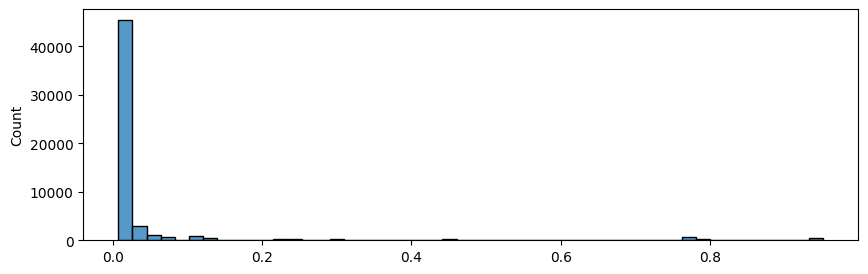

In [55]:
fig = plt.figure(figsize=(10, 3))
sns.histplot(y_probs, bins=50)

  Random Forrest (RandomSearchCV Params)  |  threshold = 0.25
  ROC-AUC                0.9102
  Avg Precision (PR-AUC) 0.6795
  F1 Score               0.6818
------------------------------------------
  Precision (PPV)        0.6785
  Recall (Sensitivity)   0.6850
  Specificity            0.9816
  NPV                    0.9822
------------------------------------------
  TP=2018  FP=956  FN=928  TN=51090

              precision    recall  f1-score   support

    Negative       0.98      0.98      0.98     52046
    Positive       0.68      0.68      0.68      2946

    accuracy                           0.97     54992
   macro avg       0.83      0.83      0.83     54992
weighted avg       0.97      0.97      0.97     54992



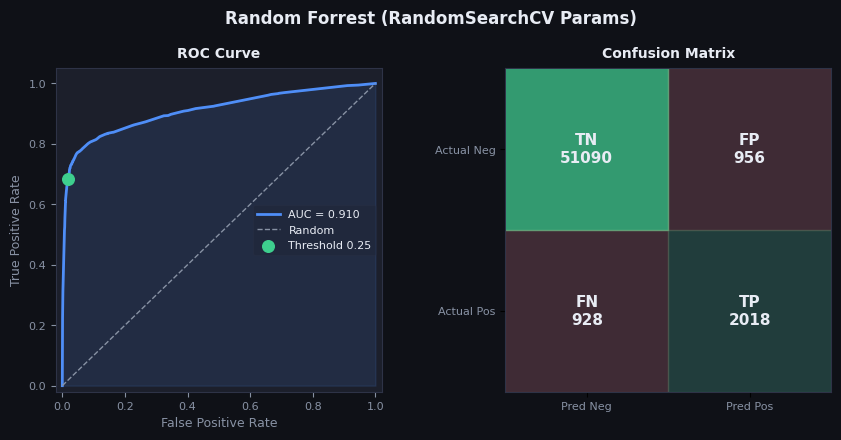

{'auc': 0.9102003322091256,
 'avg_precision': 0.6794871664496935,
 'f1': 0.6817567567567567,
 'precision': 0.6785474108944183,
 'recall': 0.6849966055668704,
 'specificity': 0.9816316335549322,
 'npv': 0.9821600215310085,
 'tp': 2018,
 'fp': 956,
 'fn': 928,
 'tn': 51090}

In [57]:
evaluate_model(
    y_true = y_test,
#     y_pred = y_pred,
    y_prob = y_probs,
    threshold=0.25,
    model_name='Random Forest (RandomSearchCV Params)'
)

In [58]:
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# print(importances)

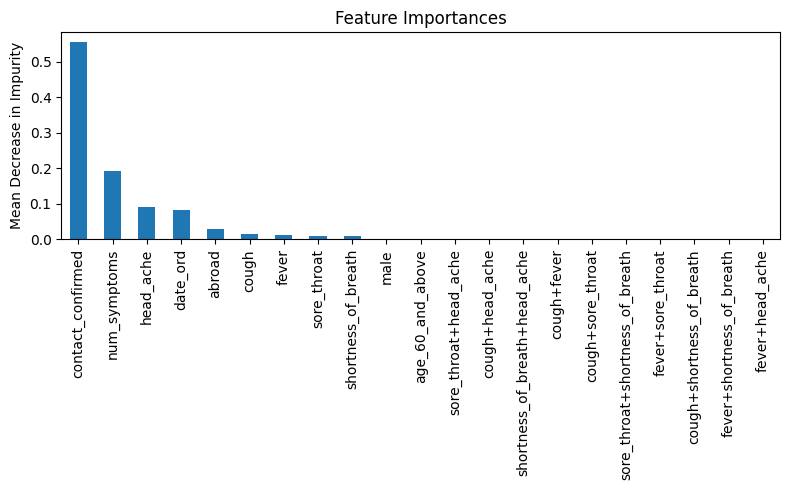

In [61]:
fig, ax = plt.subplots(figsize=(8, 5))
importances.plot.bar(ax=ax)
ax.set_title("Feature Importances")
ax.set_ylabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

In [42]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# maximise F1
f1s = [f1_score(y_test, (y_probs >= t).astype(int)) for t in thresholds]
f1_best_threshold = thresholds[np.argmax(f1s)]
print(f'F1 Maximised Threshold: {f1_best_threshold}')

F1 Maximised Threshold: 0.43284353360784084


In [424]:
evaluate_model(y_test, y_probs, threshold=f1_best_threshold)

In [425]:
# Youden's J (maximise sensitivity + specificity)
j_scores = tpr - fpr
yj_best_threshold = thresholds[np.argmax(j_scores)]
print(f'Youdens J Maximised Threshold: {yj_best_threshold}')

In [426]:
evaluate_model(y_test, y_probs, threshold=yj_best_threshold)